# Milestone 2: Week 3 & 4 - EDA & Feature Engineering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("netflix_cleaned_week3.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,duration_number,duration_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020-01-01,PG-13,90 min,Documentaries,"as her father nears the end of his life, filmm...",90.0,min
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021-01-01,TV-MA,2 seasons,"International Tv Shows, Tv Dramas, Tv Mysteries","after crossing paths at a party, a cape town t...",2.0,season
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021-01-01,TV-MA,1 season,"Crime Tv Shows, International Tv Shows, Tv Act...",to protect his family from a powerful drug lor...,1.0,season
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021-01-01,TV-MA,1 season,"Docuseries, Reality Tv","feuds, flirtations and toilet talk go down amo...",1.0,season
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021-01-01,TV-MA,2 seasons,"International Tv Shows, Romantic Tv Shows, Tv ...",in a city of coaching centers known to train i...,2.0,season


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   show_id          8807 non-null   object 
 1   type             8807 non-null   object 
 2   title            8807 non-null   object 
 3   director         8807 non-null   object 
 4   cast             8807 non-null   object 
 5   country          8807 non-null   object 
 6   date_added       8797 non-null   object 
 7   release_year     8807 non-null   object 
 8   rating           8807 non-null   object 
 9   duration         8807 non-null   object 
 10  listed_in        8807 non-null   object 
 11  description      8807 non-null   object 
 12  duration_number  8804 non-null   float64
 13  duration_type    8807 non-null   object 
dtypes: float64(1), object(13)
memory usage: 963.4+ KB


,duration_number
count,8804.000000
mean,69.846888
std,50.814828
min,1.000000
25%,2.000000
50%,88.000000
75%,106.000000
max,312.000000


# Task 1: Analyze Netflix content growth over time.

In [6]:
cols = ['date_added', 'release_year']
df[cols] = df[cols].apply(pd.to_datetime, errors='coerce')

In [7]:
df['year_added'] = df['date_added'].dt.year

In [8]:
content_growth = df['year_added'].value_counts().sort_index()
content_growth

year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      11
2014.0      24
2015.0      82
2016.0     429
2017.0    1188
2018.0    1649
2019.0    2016
2020.0    1879
2021.0    1498
Name: count, dtype: int64

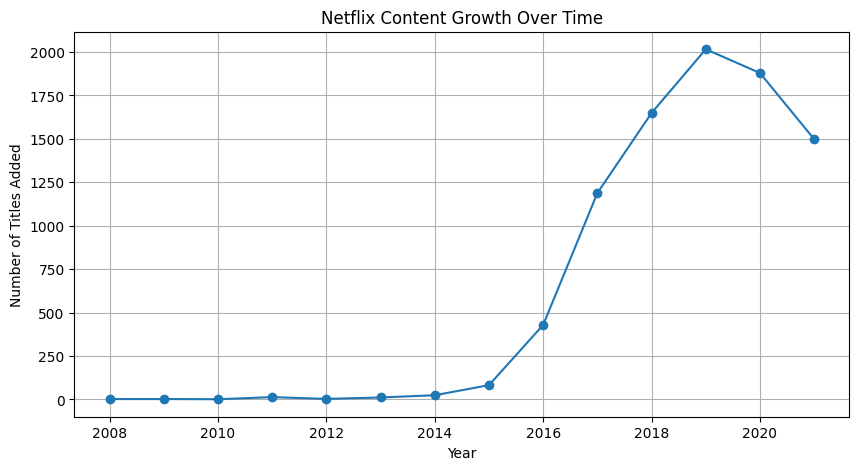

In [9]:
plt.figure(figsize=(10,5))
content_growth.plot(kind='line', marker='o')
plt.title("Netflix Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.grid(True)

plt.show()

# Task 2: Visualize the distribution of genres, ratings, and content type.

In [11]:
df['type'].value_counts()

type
Movie      6131
Tv Show    2676
Name: count, dtype: int64

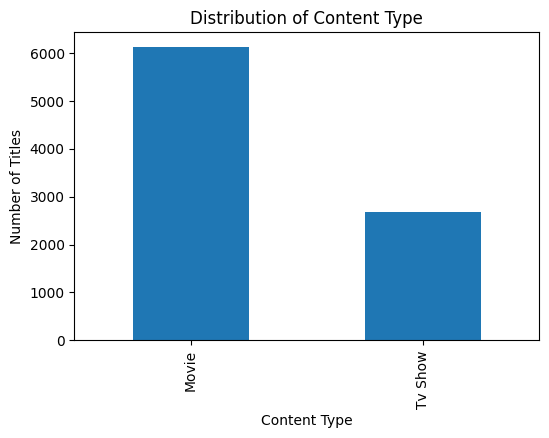

In [12]:
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar')
plt.title("Distribution of Content Type")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [13]:
df['rating'].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
UNKNOWN        4
NC-17          3
UR             3
66 MIN         1
74 MIN         1
84 MIN         1
Name: count, dtype: int64

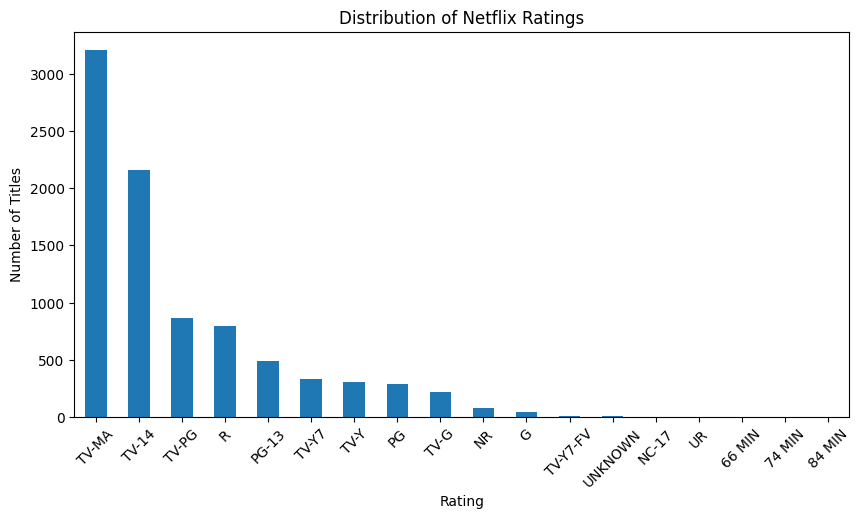

In [14]:
plt.figure(figsize=(10,5))
df['rating'].value_counts().plot(kind='bar')
plt.title("Distribution of Netflix Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

In [15]:
genres = df['listed_in'].str.split(', ').explode()

In [16]:
top_genres = genres.value_counts().head(10)
top_genres

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International Tv Shows      1351
Documentaries                869
Action & Adventure           859
Tv Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

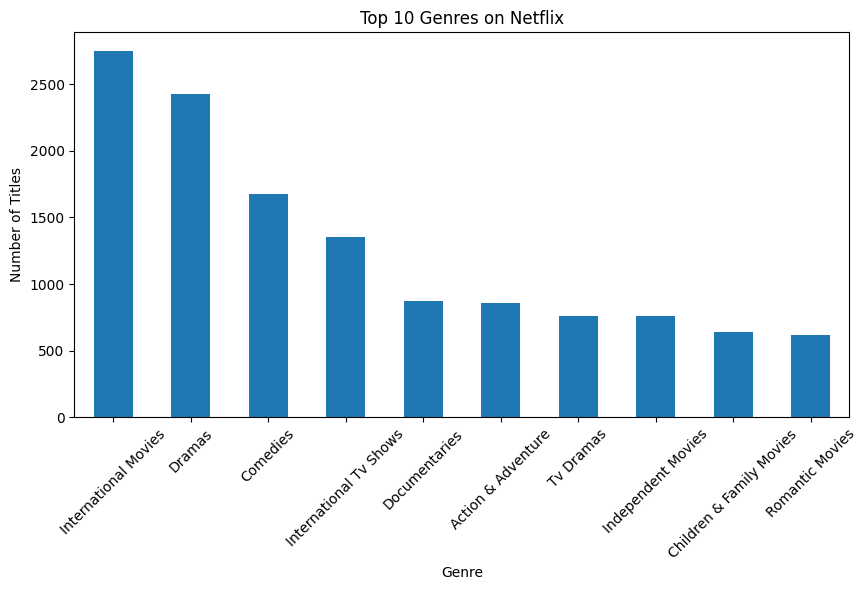

In [17]:
plt.figure(figsize=(10,5))
top_genres.plot(kind='bar')
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.show()

# Task 3: Identify country-level content contributions.

In [19]:
df['country'].head()

0    United States
1     South Africa
2          Unknown
3          Unknown
4            India
Name: country, dtype: object

In [20]:
countries = df['country'].str.split(', ').explode()

In [21]:
country_counts = countries.value_counts()
top_countries = country_counts.head(10)
top_countries

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

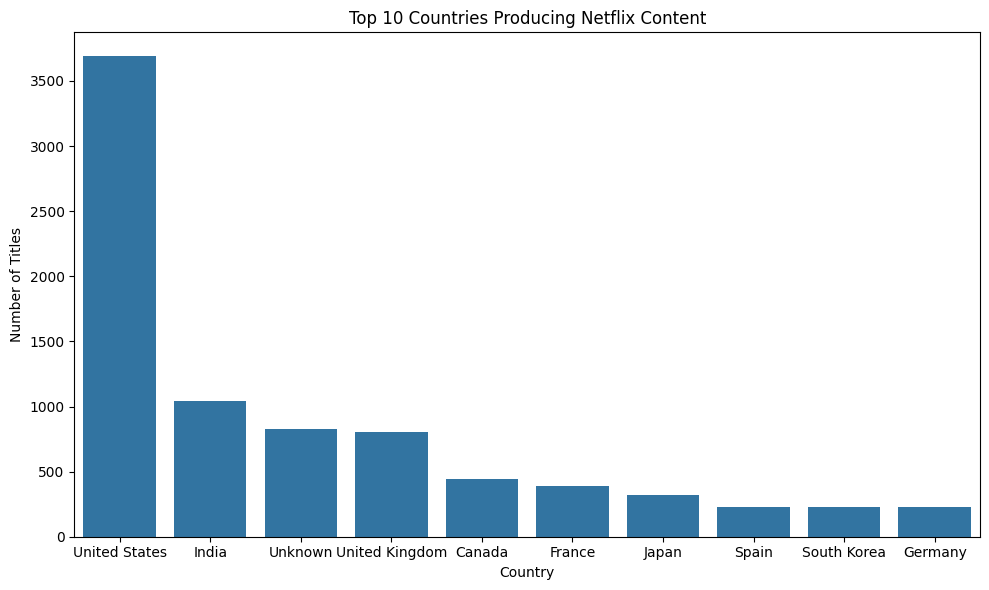

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.tight_layout()

plt.show()

# Task 4: Create derived features such as “Content Length Category” and “Original vs Licensed”.

In [24]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

In [25]:
def length_category(row):
    if row['type'] == 'Movie':
        if row['duration_num'] <= 60:
            return "Short Movie"
        elif row['duration_num'] <= 120:
            return "Medium Movie"
        else:
            return "Long Movie"
    else:
        if row['duration_num'] <= 1:
            return "Single Season Show"
        else:
            return "Multi Season Show"

In [26]:
df['content_length_category'] = df.apply(length_category, axis=1)

In [27]:
df[['type','duration','duration_num','content_length_category']].head()

,type,duration,duration_num,content_length_category
0,Movie,90 min,90.0,Medium Movie
1,Tv Show,2 seasons,2.0,Multi Season Show
2,Tv Show,1 season,1.0,Single Season Show
3,Tv Show,1 season,1.0,Single Season Show
4,Tv Show,2 seasons,2.0,Multi Season Show


In [28]:
length_counts = df['content_length_category'].value_counts()

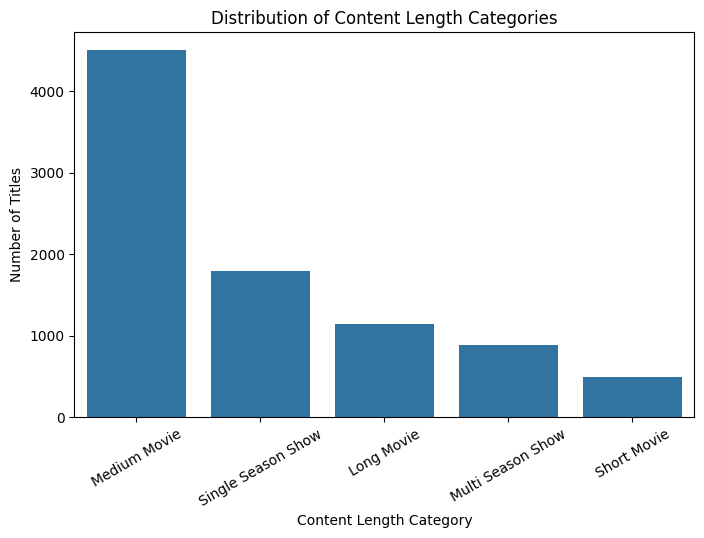

In [29]:
plt.figure(figsize=(8,5))
sns.barplot(x=length_counts.index, y=length_counts.values)
plt.title("Distribution of Content Length Categories")
plt.xlabel("Content Length Category")
plt.ylabel("Number of Titles")
plt.xticks(rotation=30)

plt.show()

In [64]:
df['year_added'] = df['date_added'].dt.year

def determine_originality(row):

    if pd.isna(row['year_added']):
        return 'Unknown'
    if row['release_year'].year == row['year_added']:
        return 'Original'
    else:
        return 'Licensed'

df['original_vs_licensed'] = df.apply(determine_originality, axis=1)

print(df['original_vs_licensed'].value_counts())

original_vs_licensed
Licensed    5556
Original    3241
Unknown       10
Name: count, dtype: int64


In [66]:
df[['title','original_vs_licensed']].head()

,title,original_vs_licensed
0,Dick Johnson Is Dead,Licensed
1,Blood & Water,Original
2,Ganglands,Original
3,Jailbirds New Orleans,Original
4,Kota Factory,Original


In [68]:
df_clean = df.copy()
df_clean.to_csv("netflix_cleaned_week4.csv", index=False)